# NOT training with ICNN 

In [ ]:
import os, sys
sys.path.append("..")

import numpy as np
import torch
import torch.nn as nn
# import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = "cuda" if torch.cuda.is_available() else "cpu"

from src.models import Transport, Critic
from src.utils import cost, show_mapping , grad_norm, cosine_lr, plot_3d_function

In [ ]:
# source distribution μ
def sample_mu(batch_size, device="cpu"):
    x = 2 * torch.rand(batch_size, 1, device=device) - 1  # [-1,1]
    y = torch.zeros(batch_size, 1, device=device)         # y = 0
    return torch.cat([x, y], dim=1)


# target distribution ν
def sample_nu(batch_size, device="cpu"):
    x = torch.zeros(batch_size, 1, device=device)         # y = 0
    y = 2 * torch.rand(batch_size, 1, device=device) - 1  # [-1,1]
    return torch.cat([x, y], dim=1)

In [ ]:
class Transport(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        z = torch.randn(x.shape[0], 1, device=x.device)
        # z = 2 * torch.rand(x.shape[0], 1, device=x.device) - 1
        return self.net(torch.cat([x, z], dim=1))

class RF_Transport(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=256, output_dim=2, scale=0.3):
        super().__init__()

        # random feature (freeze)
        self.register_buffer("W1", torch.randn(input_dim, hidden_dim) * scale)
        self.register_buffer("b1", torch.randn(hidden_dim) * scale)

        # trainable linear head
        self.W2 = nn.Parameter(torch.randn(hidden_dim, output_dim) * scale)
        self.b2 = nn.Parameter(torch.randn(output_dim)* scale)

    def forward(self, z):
        phi = nn.ReLU()
        h1 = 2 * phi(z @ self.W1 + self.b1)
        out = h1 @ self.W2 + self.b2
        return out

class RF_Critic(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=256, scale=0.3):
        super().__init__()

        # random features (fixed)
        self.register_buffer("W", torch.randn(input_dim, hidden_dim) * scale)
        self.register_buffer("b", torch.randn(hidden_dim) * scale)

        # trainable nonnegative output weight
        self.a = nn.Parameter(torch.rand(hidden_dim, 1))
        self.phi = nn.ReLU()

    def forward(self, x):
        h = self.phi(x @ self.W + self.b)

        out = 0.5 * torch.sum(x**2, dim=1, keepdim=True) - h @ self.a

        return out


In [ ]:
T = Transport().to(device)
f = RF_Critic(hidden_dim = 1000).to(device)

## Extragradient Training

step 100000, loss -9.3441


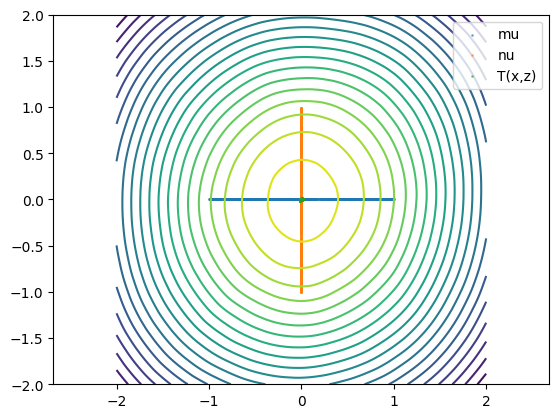

In [ ]:
lr_T = 1e-4
lr_f = 1e-4

batchsize_x = 1024
batchsize_y = 1024
for step in range(100000):
    x = sample_mu(batchsize_x).to(device)
    y = sample_nu(batchsize_y).to(device)

    T_old = [p.clone() for p in T.parameters()]
    f_old = [p.clone() for p in f.parameters()]

    # -------- critic update (maximize) --------
    Tx = T(x)
    loss = cost(x, Tx).mean() - f(Tx).mean() + f(y).mean()
    T_gradient = torch.autograd.grad(loss, T.parameters(), create_graph=True)
    f_gradient = torch.autograd.grad(loss, f.parameters())

    with torch.no_grad():
        for p, g in zip(T.parameters(), T_gradient):
            p -= lr_T * g
        for p, g in zip(f.parameters(), f_gradient):
            p += lr_f * g
    Tx2 = T(x)
    loss2 = cost(x, Tx2).mean() - f(Tx2).mean() + f(y).mean()
    T_grad_true = torch.autograd.grad(loss2, T.parameters(), create_graph=True)
    f_grad_true = torch.autograd.grad(loss2, f.parameters())

    # ----- restore parameters -----
    with torch.no_grad():
        for p, p_old in zip(T.parameters(), T_old):
            p.copy_(p_old)
        for p, p_old in zip(f.parameters(), f_old):
            p.copy_(p_old)

    with torch.no_grad():
        for p, g in zip(T.parameters(), T_grad_true):
            p -= lr_T * g
        for p, g in zip(f.parameters(), f_grad_true):
            p += lr_f * g

    if (step+1) % 500 == 0:
        clear_output(wait=True)
        print(f"step {step+1}, loss {loss.item():.4f}")
        show_mapping(T, sample_mu, sample_nu, f=f, contour = True)

## Plot Results

In [ ]:
show_mapping(T,sample_mu,sample_nu, option = False)

In [ ]:
plot_3d_function(f)